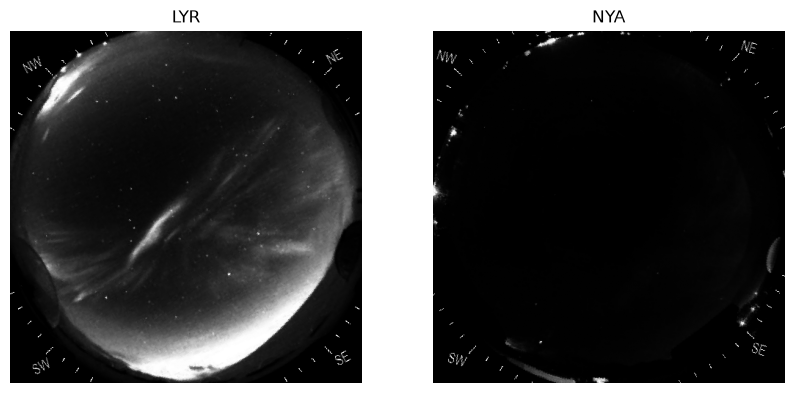

In [8]:
import os
from pathlib import Path
from datetime import datetime, timezone
from PIL import Image, ImageEnhance, ImageOps
import math
import numpy as np
import matplotlib.pyplot as plt

def rotate_and_crop(image, rotation_center, rotation_angle, border, fill=0):
    """
    指定した中心を軸に画像を回転させ、特定の領域を切り取る関数。

    パラメータ: image (PIL.
        image (PIL.Image): 操作対象の画像
        rotation_center (タプル): 回転中心の座標 (x, y) = (column, row)
        rotation_angle (float): 回転角度 (度単位)
        border (int): 拡張する境界線のサイズ
        fill (int): 境界線の色 (デフォルト: 0 = 黒)

    戻り値: PIL.
        PIL.Image: トリミングされた画像
    """
    # Expand an image with a given border
    expanded_image = ImageOps.expand(image, border, fill=fill)

    # Adjust the center of rotation to match the expanded image
    new_center = (rotation_center[0] + border, rotation_center[1] + border)

    # rotate the image at the specified center
    rotated_image = expanded_image.rotate(rotation_angle, center=new_center)

    # rage of trimming
    crop_box = (
        new_center[0] - border,
        new_center[1] - border,
        new_center[0] + border,
        new_center[1] + border
    )

    # trimming image
    cropped_image = rotated_image.crop(crop_box)

    return cropped_image


DATA = Path("Data")

save_dir = "out_geo_TEST"
os.makedirs(save_dir, exist_ok=True)

# LYR → augo1, NYA → augso (names only)
cropped_augo1 = rotate_and_crop(Image.open(DATA / "BACC_LYR2020.png"),
                               rotation_center=(302, 286), rotation_angle=28.0, border=240)
cropped_augso = rotate_and_crop(Image.open(DATA / "BACC_NYA2020.png"),
                               rotation_center=(312, 291), rotation_angle=-16.9, border=240)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cropped_augo1, cmap="gray")
ax[0].set_title("LYR")
ax[0].axis("off")
ax[1].imshow(cropped_augso, cmap="gray")
ax[1].set_title("NYA")
ax[1].axis("off")
plt.show()

xsize, ysize = cropped_augo1.size  # 480, 480
h1 = 0.0          # camera altitude in km; 0 is what the original used, the two cameras are assumed to be at the same altitude
rr = 6371.0

lat0_augo1 = 78.147778 * math.radians(1)   # LYR
lon0_augo1 = 16.039722 * math.radians(1)
lat0_augso = 78.923611 * math.radians(1)   # NYA
lon0_augso = 11.930278 * math.radians(1)

# date_time = "20200103085741"
# unixtime = int(datetime(2020, 1, 3, 8, 57, 41, tzinfo=timezone.utc).timestamp())
event = datetime(2020, 1, 3, 9, 0, 31, tzinfo=timezone.utc)
date_time = event.strftime("%Y%m%d%H%M%S")
unixtime = int(event.timestamp())


In [9]:
"""
磁力線トレーシング法の関数設定
Function settings for the magnetic field line tracing method
"""

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import os
import math
import PyGeopack as gp
from datetime import datetime, timezone
from scipy.signal import medfilt

# UNIX time → UTC
dt = datetime.fromtimestamp(unixtime, tz=timezone.utc)
# Create date in YYYYYMMDD format
dates = int(dt.strftime("%Y%m%d"))

# Calculate UT (time) (decimal format: hours + minutes/60 + seconds/3600)
ut_time = dt.hour + dt.minute / 60 + dt.second / 3600

def field_line_tracing(lat_fl, lon_fl, alt_fl, upper, lower, interval):
    """
    alt_fl を中心高度としつつ，
    実際のトレース開始点は (alt_fl + upper) にとって，
    そこから下方向にだけ磁力線をたどる版。
    A version that uses `alt_fl` as the central altitude,
    where the actual starting point of the trace is at `(alt_fl + upper)`,
    and follows the magnetic field lines only downwards from that point.
    """

    lat_fieldline = []
    lon_fieldline = []
    alt_fieldline = []

    # トレースする高度範囲（上→下）
    alt_top    = alt_fl + upper
    alt_bottom = alt_fl - lower
    alt_range  = np.arange(alt_top, alt_bottom - 1e-6, -interval)

    # 開始点は alt_top（＝ alt_fl + upper）
    r_geo = (rr + alt_top) / rr   # Re 単位

    lat_rad = np.deg2rad(lat_fl)
    lon_rad = np.deg2rad(lon_fl)

    # (x, y, z) in GEO at alt_top
    x_geo = r_geo * np.cos(lat_rad) * np.cos(lon_rad)
    y_geo = r_geo * np.cos(lat_rad) * np.sin(lon_rad)
    z_geo = r_geo * np.sin(lat_rad)

    # GEO → GSM （開始点はずっと同じ）
    x_gsm, y_gsm, z_gsm = gp.Coords.GEOtoGSM(x_geo, y_geo, z_geo, dates, ut_time)

    # alt_top から alt_bottom まで，下方向だけをトレース
    for alt in alt_range:
        trace = gp.TraceField(x_gsm, y_gsm, z_gsm,
                              dates, ut_time,
                              coord_In='GSM', alt=alt)

        lat_fieldline.append(trace.GlatN)
        lon_fieldline.append(trace.GlonN)
        alt_fieldline.append(alt)

    # ここで高度を「低→高」の昇順に並べ直しておくと，
    # 既存のプロファイル描画と同じ向きになる
        # If we reorder the altitudes here in ascending order (from ‘low’ to ‘high’),
    # the orientation will match that of the existing profile rendering
    lat_fieldline  = lat_fieldline[::-1]
    lon_fieldline  = lon_fieldline[::-1]
    alt_fieldline  = alt_fieldline[::-1]

    return lat_fieldline, lon_fieldline, alt_fieldline

cropped_augo1_np = np.array(cropped_augo1, dtype=np.uint16)
cropped_augso_np = np.array(cropped_augso, dtype=np.uint16)


def inverse_mapping(lat_fieldline, lon_fieldline, alt_fieldline, lat0, lon0, h1, rr=6371.0):
    """
    Function to find pixel coordinates on an image from latitude, longitude, and altitude.
    """
    lat_fieldline_rad = np.radians(lat_fieldline)
    lon_fieldline_rad = np.radians(lon_fieldline)

    x_points = []
    y_points = []

    for lat, lon, alt in zip(lat_fieldline_rad, lon_fieldline_rad, alt_fieldline):
        if isinstance(lat, np.ndarray):
            lat = lat.item()
        if isinstance(lon, np.ndarray):
            lon = lon.item()
        if isinstance(alt, np.ndarray):
            alt = alt.item()

        b = 0.5 * math.pi - lat
        c = 0.5 * math.pi - lat0
        aa = lon - lon0

        cosa = math.cos(b) * math.cos(c) + math.sin(b) * math.sin(c) * math.cos(aa)
        sina = math.sqrt(1.0 - cosa * cosa)

        if sina == 0:
            continue

        sinbb = math.sin(b) * math.sin(aa) / sina
        cosbb = (math.cos(b) * math.sin(c) - math.sin(b) * math.cos(c) * math.cos(aa)) / sina

        the = math.atan2((rr + alt) * sina, (rr + alt) * cosa - (rr + h1))
        l0 = 0.5 * ysize * the / (0.5 * math.pi)

        x = 0.5 * xsize + l0 * sinbb #  x = 0.5 * xsize - l0 * sinbb for East Left (ASC image)
        y = 0.5 * ysize - l0 * cosbb

        i = int(round(y))
        j = int(round(x))

        if 0 <= i < ysize and 0 <= j < xsize:
            y_points.append(i)
            x_points.append(j)

    return x_points, y_points


def rayleigh_vs_altitude(x_points_augo1, y_points_augo1, x_points_augso, y_points_augso, alt_fieldline):
    rayleigh_augo1 = []
    rayleigh_augso = []

    for x, y in zip(x_points_augo1, y_points_augo1):
        if 0 <= y < cropped_augo1_np.shape[0] and 0 <= x < cropped_augo1_np.shape[1]:
            rayleigh_augo1.append(cropped_augo1_np[int(y), int(x)] * 0.00458)
        else:
            rayleigh_augo1.append(np.nan)

    for x, y in zip(x_points_augso, y_points_augso):
        if 0 <= y < cropped_augso_np.shape[0] and 0 <= x < cropped_augso_np.shape[1]:
            rayleigh_augso.append(cropped_augso_np[int(y), int(x)] * 0.00458)
        else:
            rayleigh_augso.append(np.nan)

    rayleigh_augo1 = np.array(rayleigh_augo1)
    rayleigh_augso = np.array(rayleigh_augso)
    alt_fieldline = np.array(alt_fieldline)

    return rayleigh_augo1, rayleigh_augso, alt_fieldline

def plot_profiles_with_mean(profiles_augo1, profiles_augso, alt_fieldline, colors, labels, title_augo1="Rayleigh vs Altitude (AUGO1)", title_augso="Rayleigh vs Altitude (AUGSO)", save_path=None):
    import numpy as np
    import matplotlib.pyplot as plt

    arr_augo1 = np.vstack(profiles_augo1) if len(profiles_augo1) > 0 else np.empty((0, len(alt_fieldline)))
    arr_augso = np.vstack(profiles_augso) if len(profiles_augso) > 0 else np.empty((0, len(alt_fieldline)))

    mean_augo1 = np.nanmean(arr_augo1, axis=0) if arr_augo1.size else np.full_like(alt_fieldline, np.nan, dtype=float)
    mean_augso = np.nanmean(arr_augso, axis=0) if arr_augso.size else np.full_like(alt_fieldline, np.nan, dtype=float)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # 個別線（AUGO1）
    for prof, c, lab in zip(profiles_augo1, colors, labels):
        ax1.plot(prof, alt_fieldline, '-', lw=1.2, alpha=0.9, color=c, label=lab)
    # 平均（AUGO1）
    ax1.plot(mean_augo1, alt_fieldline, '-', lw=3.0, color='black', label='Mean')

    ax1.set_title(title_augo1, fontsize=16)
    ax1.set_xlabel("Rayleigh", fontsize=14)
    ax1.set_ylabel("Altitude (km)", fontsize=14)
    ax1.grid(True)
    ax1.legend(fontsize=8, loc='best', ncol=1)

    # 個別線（AUGSO）
    for prof, c, lab in zip(profiles_augso, colors, labels):
        ax2.plot(prof, alt_fieldline, '-', lw=1.2, alpha=0.9, color=c, label=lab)
    # 平均（AUGSO）
    ax2.plot(mean_augso, alt_fieldline, '-', lw=3.0, color='black', label='Mean')

    ax2.set_title(title_augso, fontsize=16)
    ax2.set_xlabel("Rayleigh", fontsize=14)
    ax2.grid(True)
    ax2.legend(fontsize=8, loc='best', ncol=1)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Profiles (with mean) saved at: {save_path}")

    plt.show()


    return mean_augo1, mean_augso


# Fit a cubic polynomial (3rd degree) and find the peak (maximum value)
def fit_and_find_peak_med(altitudes, rayleigh_values):
    valid_idx = ~np.isnan(rayleigh_values)
    altitudes, rayleigh_values = altitudes[valid_idx], rayleigh_values[valid_idx]

    if len(altitudes) == 0:
        return None, None, None

    rayleigh_smooth = medfilt(rayleigh_values, kernel_size=3)

    peak_idx = np.argmax(rayleigh_smooth)
    peak_altitude = altitudes[peak_idx]
    peak_rayleigh = rayleigh_smooth[peak_idx]

    return altitudes, rayleigh_smooth, (peak_altitude, peak_rayleigh)

def fit_and_find_peak(altitudes, rayleigh_values):
    valid_idx = ~np.isnan(rayleigh_values)  # Remove NaN values
    altitudes, rayleigh_values = altitudes[valid_idx], rayleigh_values[valid_idx]

    if len(altitudes) < 4:  # Not enough data for cubic fitting
        return None, None, None

    poly_coeffs = np.polyfit(altitudes, rayleigh_values, 3)  # Cubic fit
    poly_func = np.poly1d(poly_coeffs)  # Create polynomial function

    # Generate smooth curve for plotting
    alt_smooth = np.linspace(min(altitudes), max(altitudes), 100)
    rayleigh_smooth = poly_func(alt_smooth)

    # Find peak (maximum value of the fitted curve)
    peak_idx = np.argmax(rayleigh_smooth)
    peak_altitude = alt_smooth[peak_idx]
    peak_rayleigh = rayleigh_smooth[peak_idx]

    return poly_func, peak_altitude, peak_rayleigh
def plot_pixel_values_vs_altitude(rayleigh_augo1, rayleigh_augso, alt_fieldline, title_augo1, title_augso, save_path, save_condition):
    """
    Obtains the image luminance values from the specified pixel coordinates and plots the relationship between elevation and pixel values.
    Additionally, applies cubic polynomial fitting and plots the fitted curves along with peak values.

    Parameters:
        rayleigh_augo1 (list): list of Rayleigh values for AUGO1.
        rayleigh_augso (list): list of Rayleigh values for AUGSO.
        alt_fieldline (list): list of altitudes for each point.
    """

#    poly_func_augo1, peak_alt_augo1, peak_rayleigh_augo1 = fit_and_find_peak(alt_fieldline, rayleigh_augo1)
#    poly_func_augso, peak_alt_augso, peak_rayleigh_augso = fit_and_find_peak(alt_fieldline, rayleigh_augso)

    altitudes_augo1, rayleigh_smooth_augo1, (peak_alt_augo1, peak_rayleigh_augo1) = fit_and_find_peak_med(alt_fieldline, rayleigh_augo1)
    altitudes_augso, rayleigh_smooth_augso, (peak_alt_augso, peak_rayleigh_augso) = fit_and_find_peak_med(alt_fieldline, rayleigh_augso)
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Plot AUGO1
#    ax1.plot(rayleigh_augo1, alt_fieldline, 'ro-', label="cropped_augo1")  # Original data
#    if poly_func_augo1 is not None:
#        alt_smooth = np.linspace(min(alt_fieldline), max(alt_fieldline), 100)
#        ax1.plot(poly_func_augo1(alt_smooth), alt_smooth, 'r--', label="Cubic Fit")  # Fitting curve
#        ax1.plot(peak_rayleigh_augo1, peak_alt_augo1, 'rx', markersize=10, label="Peak")  # Peak point
    if altitudes_augo1 is not None:
        ax1.plot(rayleigh_augo1, alt_fieldline, 'ro-', alpha=0.5, label="Original Data")
        ax1.plot(rayleigh_smooth_augo1, altitudes_augo1, 'r-', label="Median Filtered")
        ax1.plot(peak_rayleigh_augo1, peak_alt_augo1, 'rx', markersize=10, label="Peak")

    ax1.set_ylabel("Altitude (km)", fontsize=20)
    ax1.set_xlabel("Rayleigh", fontsize=20)
    ax1.set_title(title_augo1, fontsize=20)
    ax1.legend()
    ax1.grid(True)

    # Plot AUGSO
#    ax2.plot(rayleigh_augso, alt_fieldline, 'bo-', label="cropped_augso")  # Original data
#    if poly_func_augso is not None:
#        alt_smooth = np.linspace(min(alt_fieldline), max(alt_fieldline), 100)
#        ax2.plot(poly_func_augso(alt_smooth), alt_smooth, 'b--', label="Cubic Fit")  # Fitting curve
#        ax2.plot(peak_rayleigh_augso, peak_alt_augso, 'bx', markersize=10, label="Peak")  # Peak point
    if altitudes_augso is not None:
        ax2.plot(rayleigh_augso, alt_fieldline, 'bo-', alpha=0.5, label="Original Data")
        ax2.plot(rayleigh_smooth_augso, altitudes_augso, 'b-', label="Median Filtered")
        ax2.plot(peak_rayleigh_augso, peak_alt_augso, 'bx', markersize=10, label="Peak")

    ax2.set_ylabel("Altitude (km)", fontsize=20)
    ax2.set_xlabel("Rayleigh", fontsize=20)
    ax2.set_title(title_augso, fontsize=20)
    ax2.legend()
    ax2.grid(True)
    plt.figtext(1.01, 0.5,
                f"Latitude: {lat1}° to {lat2}°\n"
                f"Longitude: {lon1}° to {lon2}°\n"
                f"Peak Altitude AUGO1: {peak_alt_augo1}\n"
                f"Peak Altitude AUGSO: {peak_alt_augso}\n",
                fontsize=16, color="black", ha="left", va="center")
    # Save the figure only if save_condition is True
    if save_path and save_condition:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Figure saved at: {save_path}")
    plt.show()

    # Store results
#    results = {
#        "AUGO1": {
#            "peak_altitude": peak_alt_augo1,
#            "peak_rayleigh": peak_rayleigh_augo1,
#        },
#        "AUGSO": {
#            "peak_altitude": peak_alt_augso,
#            "peak_rayleigh": peak_rayleigh_augso,
#        },
#    }
    print(f"Peak Altitude AUGO1: {peak_alt_augo1}")
    print(f"Peak Rayleigh AUGO1: {peak_rayleigh_augo1}")
    print(f"Peak Altitude AUGSO: {peak_alt_augso}")
    print(f"Peak Rayleigh AUGSO: {peak_rayleigh_augso}")
#    return results

def calculation_for_conditions(rayleigh_augo1, rayleigh_augso, alt_fieldline):
    """
    Parameters:
        rayleigh_augo1 (list): list of Rayleigh values for AUGO1.
        rayleigh_augso (list): list of Rayleigh values for AUGSO.
        alt_fieldline (list): list of altitudes for each point.

    Returns:
        dict: Dictionary containing correlation, peak altitude, peak Rayleigh, centre, percentile ratio,
              mean Rayleigh above peak altitude, mean Rayleigh below peak altitude for both graphs.
    """
    # Remove NaN values for correlation computation
    valid_indices = ~np.isnan(rayleigh_augo1) & ~np.isnan(rayleigh_augso)
    correlation = np.corrcoef(rayleigh_augo1[valid_indices], rayleigh_augso[valid_indices])[0, 1]

    poly_func_augo1, peak_alt_augo1, peak_rayleigh_augo1 = fit_and_find_peak(alt_fieldline, rayleigh_augo1)
    poly_func_augso, peak_alt_augso, peak_rayleigh_augso = fit_and_find_peak(alt_fieldline, rayleigh_augso)

    # Compute Centre (Σ(Rayleigh * altitude) / ΣRayleigh)
    def compute_centre(altitudes, rayleigh_values):
        valid_idx = ~np.isnan(rayleigh_values)
        altitudes, rayleigh_values = altitudes[valid_idx], rayleigh_values[valid_idx]
        return np.sum(rayleigh_values * altitudes) / np.sum(rayleigh_values) if np.sum(rayleigh_values) != 0 else np.nan

    centre_augo1 = compute_centre(alt_fieldline, rayleigh_augo1)
    centre_augso = compute_centre(alt_fieldline, rayleigh_augso)

    # Compute P (60% percentile / median)
    def compute_p(rayleigh_values):
        valid_values = rayleigh_values[~np.isnan(rayleigh_values)]
        if len(valid_values) == 0:
            return np.nan
        percentile_60 = np.percentile(valid_values, 60)
        median_rayleigh = np.median(valid_values)
        return percentile_60 / median_rayleigh if median_rayleigh != 0 else np.nan

    p_augo1 = compute_p(rayleigh_augo1)
    p_augso = compute_p(rayleigh_augso)

    # Compute mean Rayleigh above and below peak altitude
    def mean_above_below_peak(altitudes, rayleigh_values, peak_altitude):
        valid_idx = ~np.isnan(rayleigh_values)
        altitudes, rayleigh_values = altitudes[valid_idx], rayleigh_values[valid_idx]

        above = rayleigh_values[altitudes > peak_altitude]
        below = rayleigh_values[altitudes < peak_altitude]

        mean_above = np.mean(above) if len(above) > 0 else np.nan
        mean_below = np.mean(below) if len(below) > 0 else np.nan

        return mean_above, mean_below

    mean_above_augo1, mean_below_augo1 = mean_above_below_peak(alt_fieldline, rayleigh_augo1, peak_alt_augo1)
    mean_above_augso, mean_below_augso = mean_above_below_peak(alt_fieldline, rayleigh_augso, peak_alt_augso)

    # Store results
    #print(f"Correlation: {correlation}")
    #print(f"Peak Altitude AUGO1: {peak_alt_augo1}")
    #print(f"Peak Rayleigh AUGO1: {peak_rayleigh_augo1}")
    #print(f"Centre AUGO1: {centre_augo1}")
    #print(f"P AUGO1: {p_augo1}")
    #print(f"Mean Rayleigh Above Peak AUGO1: {mean_above_augo1}")
    #print(f"Mean Rayleigh Below Peak AUGO1: {mean_below_augo1}")
    #print(f"Peak Altitude AUGSO: {peak_alt_augso}")
    #print(f"Peak Rayleigh AUGSO: {peak_rayleigh_augso}")
    #print(f"Centre AUGSO: {centre_augso}")
    #print(f"P AUGSO: {p_augso}")
    #print(f"Mean Rayleigh Above Peak AUGSO: {mean_above_augso}")
    #print(f"Mean Rayleigh Below Peak AUGSO: {mean_below_augso}")

    return correlation, peak_alt_augo1, peak_rayleigh_augo1, centre_augo1, p_augo1, mean_above_augo1, mean_below_augo1, peak_alt_augso, peak_rayleigh_augso, centre_augso, p_augso, mean_above_augso, mean_below_augso
def monte_carlo_peak_error_with_se(altitudes, rayleigh_values, rayleigh_std, sample_size, num_simulations=1000):
    """
    Function to find the error range of a peak using the Monte Carlo method (considering standard error).
    Parameters:.
        altitudes (np.array): An array of altitudes.
        rayleigh_values (np.array): array of Rayleigh values
        rayleigh_std (np.array): array of standard deviations of Rayleigh values at each altitude.
        sample_size (int): number of samples at each altitude
        num_simulations (int): number of simulations.
    Returns: An array of
        tuple: (mean of peak altitude, standard error of peak altitude, mean of peak Rayleigh values, standard error of peak Rayleigh values)
    """

    peak_altitudes = []
    peak_rayleighs = []

    valid_idx = ~np.isnan(rayleigh_values)
    altitudes = altitudes[valid_idx]
    rayleigh_values = rayleigh_values[valid_idx]
    rayleigh_std = rayleigh_std[valid_idx]

    if len(altitudes) == 0:
        return np.nan, np.nan, np.nan, np.nan

    # Calculate standard error
    rayleigh_se = rayleigh_std / np.sqrt(sample_size)

    for _ in range(num_simulations):
        noisy_rayleigh = rayleigh_values + np.random.normal(0, rayleigh_se, size=len(rayleigh_values))
        smoothed_rayleigh = medfilt(noisy_rayleigh, kernel_size=3)
        peak_idx = np.argmax(smoothed_rayleigh)
        peak_altitudes.append(altitudes[peak_idx])
        peak_rayleighs.append(smoothed_rayleigh[peak_idx])

    return (np.mean(peak_altitudes), np.std(peak_altitudes), np.mean(peak_rayleighs), np.std(peak_rayleighs))

# --- 1) 追加：下からトレース関数 -----------------------------------------
def field_line_tracing_bottomup(lat_fl, lon_fl, alt_fl, upper, lower, interval):  # NEW
    """
    (lat_fl, lon_fl, alt_bottom) から上方向だけをトレースする版
    """
    lat_fieldline = []
    lon_fieldline = []
    alt_fieldline = []

    alt_bottom = alt_fl - lower
    alt_top    = alt_fl + upper
    alt_range  = np.arange(alt_bottom, alt_top + 1e-6, interval)

    # 開始点は alt_bottom
    r_geo = (rr + alt_bottom) / rr

    lat_rad = np.deg2rad(lat_fl)
    lon_rad = np.deg2rad(lon_fl)

    x_geo = r_geo * np.cos(lat_rad) * np.cos(lon_rad)
    y_geo = r_geo * np.cos(lat_rad) * np.sin(lon_rad)
    z_geo = r_geo * np.sin(lat_rad)

    x_gsm, y_gsm, z_gsm = gp.Coords.GEOtoGSM(x_geo, y_geo, z_geo, dates, ut_time)

    for alt in alt_range:
        trace = gp.TraceField(x_gsm, y_gsm, z_gsm, dates, ut_time, coord_In='GSM', alt=alt)
        lat_fieldline.append(trace.GlatN)
        lon_fieldline.append(trace.GlonN)
        alt_fieldline.append(alt)

    # 上下で向きをそろえる（低→高に昇順）
    return lat_fieldline, lon_fieldline, alt_fieldline  # NEW
# --------------------------------------------------------------------------


# --- 2) 追加：top-down / bottom-up を別々に並べて描くプロット -------------
def plot_profiles_top_bottom(
    td_profiles_augo1, td_profiles_augso,
    bu_profiles_augo1, bu_profiles_augso,
    alt_fieldline, colors_td, labels_td, colors_bu, labels_bu,
    save_path=None
):
    import numpy as np
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)

    def _one(ax, profiles, colors, labels, title):
        arr = np.vstack(profiles) if profiles else np.empty((0, len(alt_fieldline)))
        mean = np.nanmean(arr, axis=0) if arr.size else np.full_like(alt_fieldline, np.nan, float)

        for prof, c, lab in zip(profiles, colors, labels):
            ax.plot(prof, alt_fieldline, lw=1.2, alpha=0.9, color=c, label=lab)

        ax.plot(mean, alt_fieldline, '-', lw=3.0, color='black', label='Mean')
        ax.set_title(title)
        ax.set_xlabel("Rayleigh")
        ax.grid(True)

        # ★ 凡例を外側へ
        ax.legend(
            fontsize=8,
            loc='upper left',
            bbox_to_anchor=(1.02, 1.0),    # ← パネルの右に配置
            borderaxespad=0.
        )

        return mean

    mean_td_augo1 = _one(axes[0,0], td_profiles_augo1, colors_td, labels_td, "Top-down (AUGO1)")
    mean_td_augso = _one(axes[0,1], td_profiles_augso, colors_td, labels_td, "Top-down (AUGSO)")
    mean_bu_augo1 = _one(axes[1,0], bu_profiles_augo1, colors_bu, labels_bu, "Bottom-up (AUGO1)")
    mean_bu_augso = _one(axes[1,1], bu_profiles_augso, colors_bu, labels_bu, "Bottom-up (AUGSO)")

    axes[0,0].set_ylabel("Altitude (km)")
    axes[1,0].set_ylabel("Altitude (km)")

    plt.tight_layout(rect=[0, 0, 0.85, 1])  # ← 右の凡例分のスペースを確保

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

    return mean_td_augo1, mean_td_augso, mean_bu_augo1, mean_bu_augso
# --------------------------------------------------------------------------

def compute_peak_width(altitudes, rayleigh_values, frac):
    """
    altitudes:  高度配列（昇順）
    rayleigh_values: Rayleigh 配列（同じ長さ、NaN含み可）
    frac: ピーク値の何 % で幅を測るか（0.9 なら 90% 幅）

    Returns:
        width_km : 幅 [km]（high - low）
        low_alt  : 閾値を下回り始める高度
        high_alt : 閾値を下回り始める高度（上側）
    """
    altitudes = np.asarray(altitudes)
    rayleigh_values = np.asarray(rayleigh_values)

    # 有効データだけ抜き出し
    valid = np.isfinite(rayleigh_values)
    if valid.sum() < 3:
        return np.inf, np.nan, np.nan  # 幅条件ではじくために ∞ を返す

    alts = altitudes[valid]
    vals = rayleigh_values[valid]

    # 少し滑らかにする（fit_and_find_peak_med と同じノリ）
    smooth = medfilt(vals, kernel_size=3)

    # ピーク
    peak_idx = np.argmax(smooth)
    peak_alt = alts[peak_idx]
    peak_val = smooth[peak_idx]
    if peak_val <= 0:
        return np.inf, np.nan, np.nan

    threshold = peak_val * frac

    # 下側方向にたどる
    i_low = peak_idx
    while i_low > 0 and smooth[i_low] >= threshold:
        i_low -= 1
    low_alt = alts[i_low]

    # 上側方向にたどる
    i_high = peak_idx
    n = len(alts) - 1
    while i_high < n and smooth[i_high] >= threshold:
        i_high += 1
    high_alt = alts[i_high]

    width_km = high_alt - low_alt
    return width_km, low_alt, high_alt

from scipy.signal import medfilt

# ------------------------------------------------------------
# 1) 1リージョン分だけを処理するヘルパー
# A helper that processes data from just one region
# ------------------------------------------------------------
def trace_and_filter_single_region(
    lat_range, lon_range, alt_fl,
    step, upper, lower, interval,
    peak, corr_thr, edge, frac, width_limit, median_thr,
    make_plots=True,
    save_prefix=None
):
    """
    1つの (lat_range, lon_range) に対してフィールドラインをトレースし，
    条件を満たしたフィールドラインの情報を返す。
    Traces field lines for a given (lat_range, lon_range) and
    returns information on the field lines that satisfy the conditions.
    """

    lat_fl_values = np.arange(*lat_range, step)
    lon_fl_values = np.arange(*lon_range, step)

    # 条件を満たしたラインのプロファイル・座標を溜める
    all_rayleigh_augo1 = []
    all_rayleigh_augso = []
    lines_augo1 = []
    lines_augso = []

    alt_fieldline_last = None
    sample_size = 0

    for lat_fl in lat_fl_values:
        for lon_fl in lon_fl_values:

            # --- field-line tracing（上から下へ） ------------------------
            lat_td, lon_td, alt_td = field_line_tracing(
                lat_fl, lon_fl, alt_fl, upper, lower, interval
            )

            x1_td, y1_td = inverse_mapping(
                lat_td, lon_td, alt_td,
                lat0_augo1, lon0_augo1, h1
            )
            x2_td, y2_td = inverse_mapping(
                lat_td, lon_td, alt_td,
                lat0_augso,  lon0_augso,  h1
            )

            r1_td, r2_td, alt_td = rayleigh_vs_altitude(
                x1_td, y1_td, x2_td, y2_td, alt_td
            )

            # プロファイルの特徴量などを算出
            corr_td, palt1_td, pray1_td, cen1_td, p1_td, ma1_td, mb1_td, \
                palt2_td, pray2_td, cen2_td, p2_td, ma2_td, mb2_td = \
                calculation_for_conditions(r1_td, r2_td, alt_td)

            # 半値幅（90%幅）を計算
            width90_augo1_td, low90_augo1_td, high90_augo1_td = \
                compute_peak_width(alt_td, r1_td, frac=frac)
            width90_augso_td, low90_augso_td, high90_augso_td = \
                compute_peak_width(alt_td, r2_td, frac=frac)

            # --- 採択条件 ------------------------------------------------
            cond = (
                abs(palt1_td - palt2_td) < peak and
                alt_fl - lower + edge < palt1_td < alt_fl + upper - edge and
                alt_fl - lower + edge < palt2_td < alt_fl + upper - edge and
                abs(cen1_td - cen2_td) < median_thr and
                corr_td > corr_thr and
                (pray1_td > ma1_td * p1_td or pray1_td > mb1_td * p1_td) and
                (pray2_td > ma2_td * p2_td or pray2_td > mb2_td * p2_td) and
                width90_augo1_td <= width_limit and
                width90_augso_td <= width_limit
            )

            if cond:
                all_rayleigh_augo1.append(np.array(r1_td))
                all_rayleigh_augso.append(np.array(r2_td))

                lines_augo1.append(
                    (np.asarray(x1_td).ravel(), np.asarray(y1_td).ravel())
                )
                lines_augso.append(
                    (np.asarray(x2_td).ravel(), np.asarray(y2_td).ravel())
                )

                alt_fieldline_last = np.array(alt_td)
                sample_size += 1

    if sample_size == 0 or alt_fieldline_last is None:
        print(f"[{lat_range}, {lon_range}] No valid field lines.")
        return [], [], np.array([]), [], []

    # =================================================================
    # ここから「このリージョン単独の図」を描くパート
    # This is the section where we draw a ‘diagram of this region alone’
    # =================================================================
    if make_plots:
        label_str = f"lat={lat_range[0]}–{lat_range[1]}, lon={lon_range[0]}–{lon_range[1]}"

        # ----------------- (A) 全天画像 + フィールドライン -----------------
        fig_im, (ax_im1, ax_im2) = plt.subplots(1, 2, figsize=(12, 6))
        # flipped_augo1 = cropped_augo1_np[:, ::-1]
        # flipped_augso = cropped_augso_np[:, ::-1]
        flipped_augo1 = cropped_augo1_np
        flipped_augso = cropped_augso_np
        ax_im1.imshow(flipped_augo1, cmap='gray')
        ax_im2.imshow(flipped_augso, cmap='gray')
        ax_im1.set_title(f"AUGO1: {label_str}")
        ax_im2.set_title(f"AUGSO: {label_str}")

        # 色のサイクル
        colors_cycle = [
            "#ff0000","#ff4000","#ff8000","#ffbf00","#ffff00",
            "#bfff00","#80ff00","#40ff00","#00ff80","#00ffbf",
            "#00ffff","#00bfff","#0080ff","#0040ff","#0000ff"
        ]
        line_colors = []   # ← CHANGED: 各ラインの色を記録

        for idx, ((x1, y1), (x2, y2)) in enumerate(zip(lines_augo1, lines_augso)):
            c = colors_cycle[idx % len(colors_cycle)]
            line_colors.append(c)   # ← CHANGED
            ax_im1.scatter(x1, y1, c=c, s=2,
                           label=f"line {idx+1}" if idx < len(colors_cycle) else None)
            ax_im2.scatter(x2, y2, c=c, s=2,
                           label=f"line {idx+1}" if idx < len(colors_cycle) else None)

        # 凡例（重複除去）
        def uniq_legend(ax):
            h, l = ax.get_legend_handles_labels()
            if not h:
                return
            uniq = dict(zip(l, h))
            ax.legend(uniq.values(), uniq.keys(),
                      loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8)

        uniq_legend(ax_im1)
        uniq_legend(ax_im2)

        plt.tight_layout()
        if save_prefix is not None:
            path_im = os.path.join(save_dir, f"{save_prefix}_fieldlines_single.png")
            plt.savefig(path_im, bbox_inches="tight")
            print(f"Saved: {path_im}")
        plt.show()

        # ----------------- (B) Rayleigh–Altitude プロファイル ---------------
        arr1 = np.vstack(all_rayleigh_augo1)  # (n_line, n_alt)
        arr2 = np.vstack(all_rayleigh_augso)

        mean1 = np.nanmean(arr1, axis=0)
        mean2 = np.nanmean(arr2, axis=0)

        mean1_s = medfilt(mean1, kernel_size=3)
        mean2_s = medfilt(mean2, kernel_size=3)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        alt = alt_fieldline_last

        # ------------------------------------------------------------
        # ★ Peak detection（平均プロファイルのピークを求める）
        # ------------------------------------------------------------
        idx_pk1 = np.nanargmax(mean1_s)    # ←★追加
        pk_ray1 = mean1_s[idx_pk1]         # ←★追加
        pk_alt1 = alt[idx_pk1]             # ←★追加

        idx_pk2 = np.nanargmax(mean2_s)    # ←★追加
        pk_ray2 = mean2_s[idx_pk2]         # ←★追加
        pk_alt2 = alt[idx_pk2]             # ←★追加

        print(f"{label_str} AUGO1:{pk_alt1}, AUGSO:{pk_alt2}")

        # AUGO1: 各ラインをカラーで表示（±1σなし）  # ← CHANGED
        for prof, c in zip(all_rayleigh_augo1, line_colors):
            ax1.plot(prof, alt, color=c, alpha=0.8, lw=1.2)
        # 黒太線で平均（スムージング済み）
        ax1.plot(mean1_s, alt, color='black', lw=2.5, label='Mean (smoothed)')
        ax1.set_xlabel("Rayleigh")
        ax1.set_ylabel("Altitude (km)")
        ax1.set_title(f"AUGO1 {label_str}")
        ax1.grid(True)
        ax1.legend(loc='best')

        # AUGSO: 同じ色対応で表示  # ← CHANGED
        for prof, c in zip(all_rayleigh_augso, line_colors):
            ax2.plot(prof, alt, color=c, alpha=0.8, lw=1.2)
        ax2.plot(mean2_s, alt, color='black', lw=2.5, label='Mean (smoothed)')
        ax2.set_xlabel("Rayleigh")
        ax2.set_title(f"AUGSO {label_str}")
        ax2.grid(True)
        ax2.legend(loc='best')

        plt.tight_layout()
        if save_prefix is not None:
            path_prof = os.path.join(save_dir, f"{save_prefix}_profiles_single.png")
            plt.savefig(path_prof, bbox_inches="tight")
            print(f"Saved: {path_prof}")
        plt.show()

    # ---- データを返す（multi-region 用でも使える） -------------------
    return all_rayleigh_augo1, all_rayleigh_augso, alt_fieldline_last, lines_augo1, lines_augso

# ------------------------------------------------------------
# 2) 複数リージョンをまとめて処理 & 図を描くメイン関数
#    （trace_and_filter_field_lines をこの形に差し替え）
# Main function for processing multiple regions in bulk & plotting diagrams
#    (Replace `trace_and_filter_field_lines` with this version)
# ------------------------------------------------------------
def trace_and_filter_field_lines(
    regions, colors,
    alt_fl, step, upper, lower, interval,
    peak, corr_thr, edge, frac, width_limit, median_thr,
    save_prefix=None
):
    """
    regions : list of dict
        例:
        regions = [
            {'lat1':52, 'lat2':54, 'lon1':-114, 'lon2':-112, 'label':'R1'},
            {'lat1':52, 'lat2':54, 'lon1':-113, 'lon2':-111, 'label':'R2'},
            {'lat1':52, 'lat2':54, 'lon1':-112, 'lon2':-110, 'label':'R3'}
        ]
    colors  : list of str
        各 region に対応する色（'red', 'limegreen', ...）

    役割：
      - すべてのリージョンで Single-region トレースを実行
      - 全天画像に R1–R3 のフィールドラインを色分け表示
      - 横長の Rayleigh–Altitude 図に R1–R3 の平均±1σ を表示
    """

    # ---- すべてのリージョンの結果を保存する辞書 ----
    region_data = {}
    common_alt = None  # 全リージョンで共通の高度配列（前提）

    for reg, col in zip(regions, colors):
        lat_range = (reg['lat1'], reg['lat2'])
        lon_range = (reg['lon1'], reg['lon2'])

        profs1, profs2, alt_arr, lines1, lines2 = trace_and_filter_single_region(
            lat_range, lon_range, alt_fl,
            step, upper, lower, interval,
            peak, corr_thr, edge, frac, width_limit, median_thr,
            make_plots=True, save_prefix=save_prefix
        )

        if len(profs1) == 0 or alt_arr.size == 0:
            continue

        if common_alt is None:
            common_alt = alt_arr
        else:
            # alt の長さが違うと扱いづらいので，違っていたら警告してスキップ
            if len(common_alt) != len(alt_arr) or not np.allclose(common_alt, alt_arr):
                print(f"Warning: altitude grid mismatch in {reg['label']}; skip.")
                continue

        region_data[reg['label']] = {
            "color": col,
            "alt": alt_arr,
            "profs_augo1": [np.array(p) for p in profs1],
            "profs_augso": [np.array(p) for p in profs2],
            "lines_augo1": lines1,
            "lines_augso": lines2,
        }

    if not region_data:
        print("No region produced valid field lines.")
        return

    # ========================================================
    #  (1) 全天画像にフィールドラインを色分け表示 
    # Displaying field lines in different colours on an all-sky image
    # ========================================================
    fig_im, (ax_im1, ax_im2) = plt.subplots(1, 2, figsize=(12, 6))
    # flipped_augo1 = cropped_augo1_np[:, ::-1]
    # flipped_augso = cropped_augso_np[:, ::-1]
    flipped_augo1 = cropped_augo1_np #The BACC images are already flipped
    flipped_augso = cropped_augso_np
    ax_im1.imshow(flipped_augo1, cmap='gray')
    ax_im2.imshow(flipped_augso, cmap='gray')
    ax_im1.set_title("AUGO1: all regions", fontsize=20)
    ax_im2.set_title("AUGSO: all regions", fontsize=20)

    for label, data in region_data.items():
        col = data["color"]

        # AUGO1
        for (x_arr, y_arr) in data["lines_augo1"]:
            ax_im1.scatter(
                x_arr, y_arr,
                c=col, s=2, label=label
            )
        # AUGSO
        for (x_arr, y_arr) in data["lines_augso"]:
            ax_im2.scatter(
                x_arr, y_arr,
                c=col, s=2, label=label
            )


    # 凡例は重複ラベルをまとめる
    def uniq_legend(ax):
        handles, labels = ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), loc='upper right', fontsize=15, framealpha=0.8)

    uniq_legend(ax_im1)
    uniq_legend(ax_im2)

    plt.tight_layout()
    if save_prefix is not None:
        path_im = os.path.join(save_dir, f"{save_prefix}_all_regions_fieldlines.png")
        plt.savefig(path_im, bbox_inches="tight")
        print(f"Saved: {path_im}")
    plt.show()

    # ========================================================
    #  (2) 横長の Rayleigh–Altitude 図（平均 ±1σ）
    # ========================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for label, data in region_data.items():
        col = data["color"]
        alt = data["alt"]

        arr1 = np.vstack(data["profs_augo1"])  # (n_line, n_alt)
        arr2 = np.vstack(data["profs_augso"])

        mean1 = np.nanmean(arr1, axis=0)
        std1  = np.nanstd(arr1,  axis=0)
        mean2 = np.nanmean(arr2, axis=0)
        std2  = np.nanstd(arr2,  axis=0)

        # メディアンフィルタで平滑化（ピークを見やすく）
        mean1_s = medfilt(mean1, kernel_size=3)
        mean2_s = medfilt(mean2, kernel_size=3)

        # --- AUGO1 ---
        ax1.fill_betweenx(alt, mean1 - std1, mean1 + std1,
                          color=col, alpha=0.15)
        ax1.plot(mean1, alt, color=col, alpha=0.5, lw=1.0)
        ax1.plot(mean1_s, alt, color=col, lw=2.0, label=label)

        # --- AUGSO ---
        ax2.fill_betweenx(alt, mean2 - std2, mean2 + std2,
                          color=col, alpha=0.15)
        ax2.plot(mean2, alt, color=col, alpha=0.5, lw=1.0)
        ax2.plot(mean2_s, alt, color=col, lw=2.0, label=label)

    ax1.set_xlabel("Rayleigh", fontsize=20)
    ax1.set_ylabel("Altitude (km)", fontsize=20)
    ax1.set_title("Rayleigh vs Alt (AUGO1) — region means ±1σ", fontsize=20)
    ax1.grid(True)
    ax1.legend(loc="best")

    ax2.set_xlabel("Rayleigh", fontsize=14)
    ax2.set_title("Rayleigh vs Alt (AUGSO) — region means ±1σ", fontsize=20)
    ax2.grid(True)
    ax2.legend(loc="best")

    plt.tight_layout()
    if save_prefix is not None:
        path_prof = os.path.join(save_dir, f"{save_prefix}_region_means.png")
        plt.savefig(path_prof, bbox_inches="tight")
        print(f"Saved: {path_prof}")
    plt.show()
    return region_data


Saved: out_geo_TEST/20200103090031_fieldlines_single.png


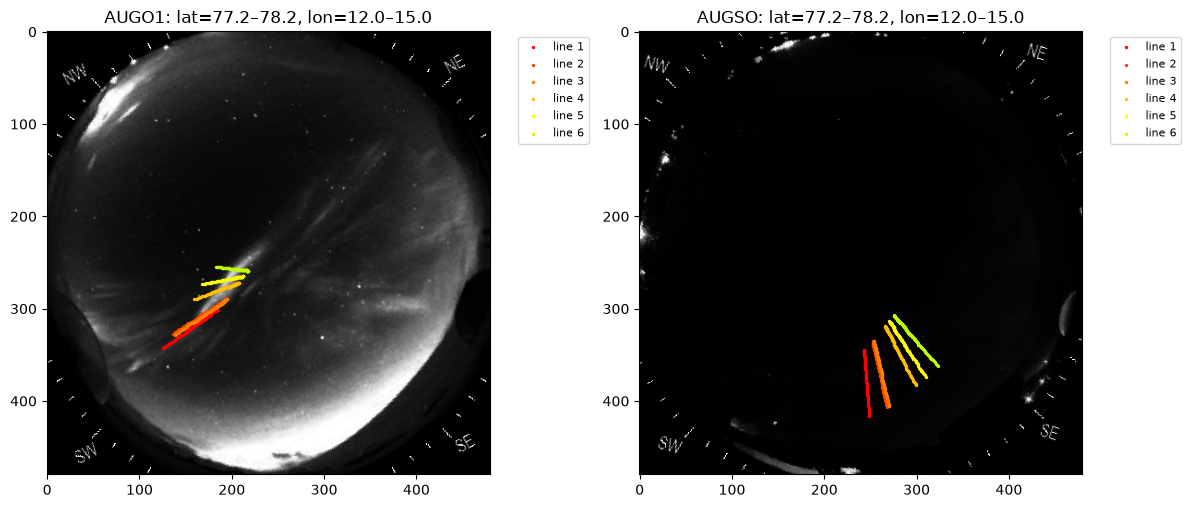

lat=77.2–78.2, lon=12.0–15.0 AUGO1:142.0, AUGSO:162.0
Saved: out_geo_TEST/20200103090031_profiles_single.png


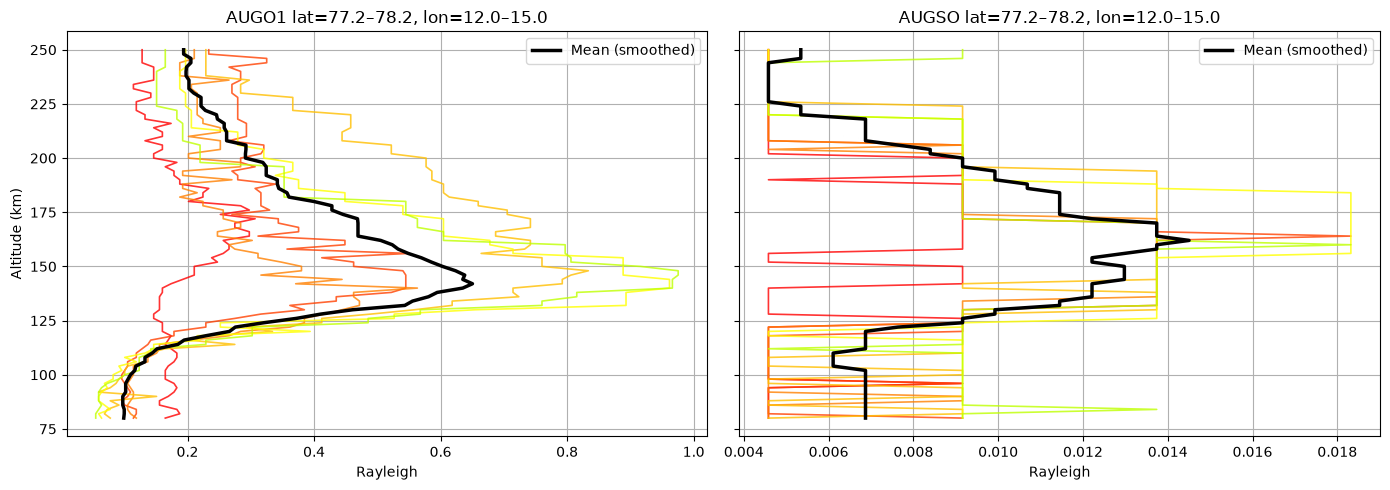

Saved: out_geo_TEST/20200103090031_all_regions_fieldlines.png


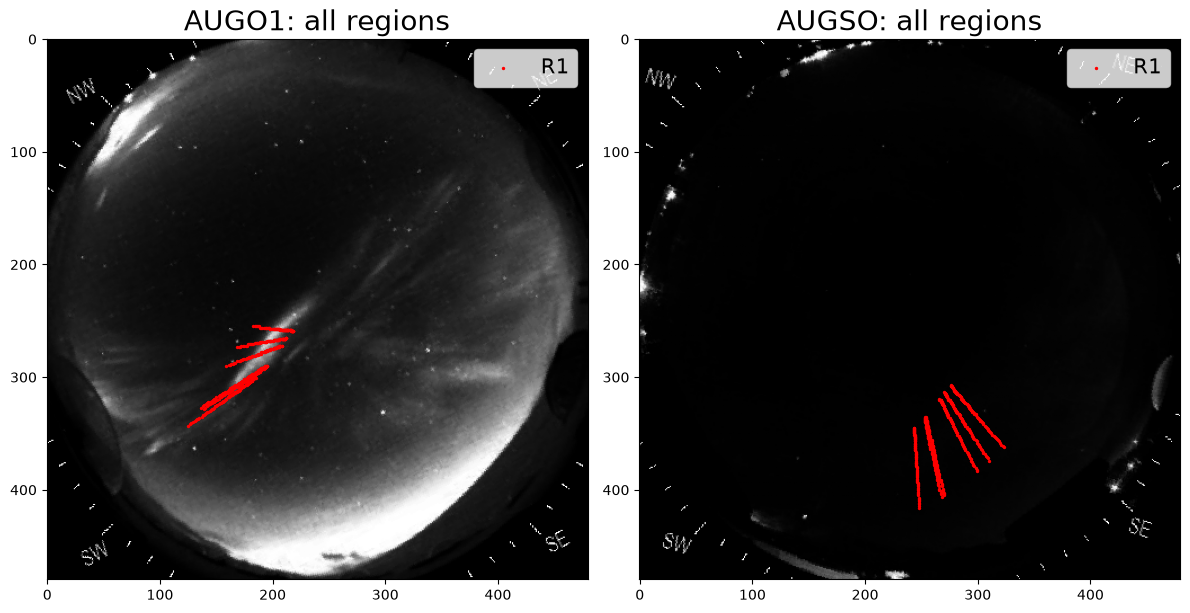

Saved: out_geo_TEST/20200103090031_region_means.png


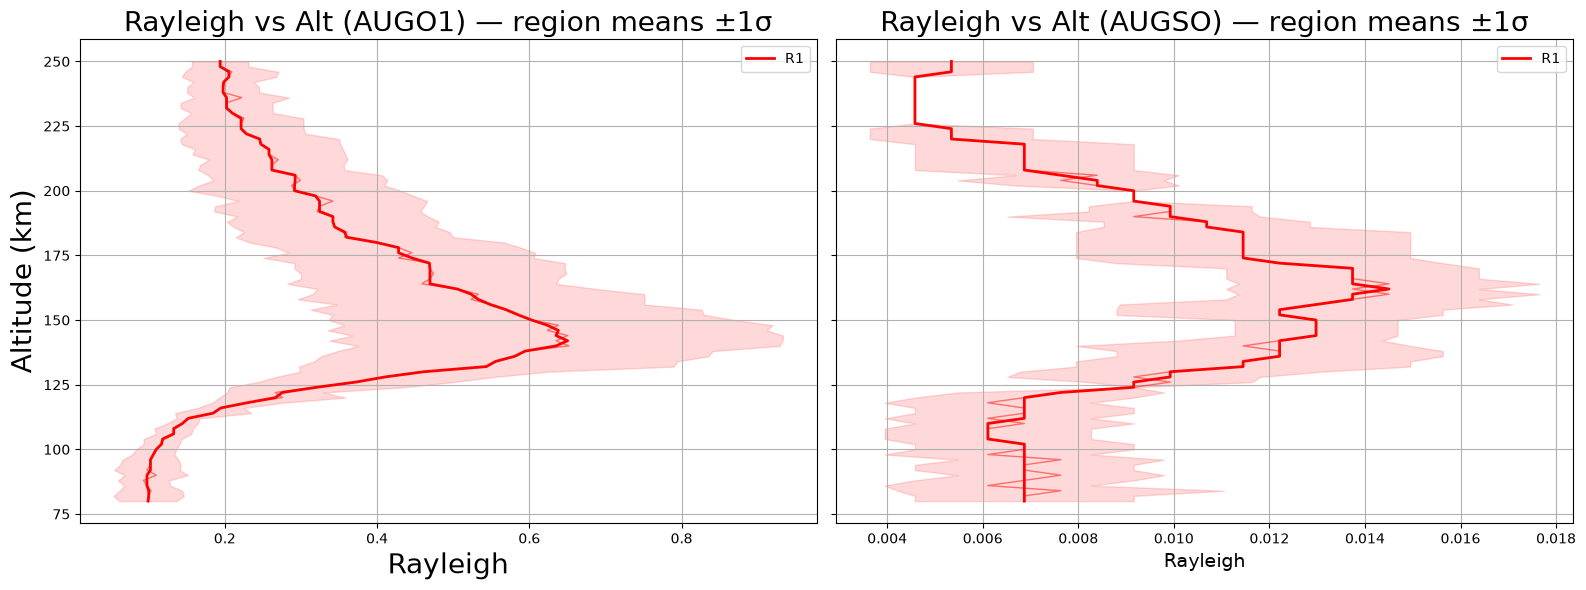

In [10]:
"""
いくつかの緯度経度範囲に対する
磁力線トレーシング法による高度プロファイル作成
（例）
緯度経度範囲
regions = [
    {'lat1':52, 'lat2':54, 'lon1':-111, 'lon2':-109, 'label':'R1'},
    {'lat1':53, 'lat2':54, 'lon1':-112.5, 'lon2':-111, 'label':'R2'},
    {'lat1':54, 'lat2':55, 'lon1':-112.5, 'lon2':-111, 'label':'R3'}
]

高度範囲：55km~150km 2kmおき（基準値alt_fl=100, 上upper=50km, 下lower=45km, interval=2km)
磁力線トレーシングの条件
二地点の高度プロファイルのピークの差：5km peak=5
二地点の高度プロファイルの相関係数 0.8以上 corr_thr=0.8
二地点それぞれのピークが高度範囲の上端下端10kmに入っていないか　edge=10
二地点それぞれのピークがしっかりとあり、90％幅40km以上　frac=0.9, width_limit=40
二地点の中央値の差20km以内 median_thr=20
region_data=trace_and_filter_field_lines(
    regions, colors,
    alt_fl=100, step=0.1,
    upper=50, lower=45, interval=2,
    peak=5, corr_thr=0.8, edge=10, width_limit=40,
    save_prefix=date_time
)

"""

# regions = [
#     {'lat1': 78.2, 'lat2': 78.6, 'lon1': 13.0, 'lon2': 15.0, 'label': 'R1'},
#     {'lat1': 78.4, 'lat2': 78.8, 'lon1': 12.5, 'lon2': 14.5, 'label': 'R2'},
#     {'lat1': 78.6, 'lat2': 79.0, 'lon1': 12.0, 'lon2': 14.0, 'label': 'R3'},
# ]

# colors = ['red', 'green', 'deepskyblue']

regions = [
    {'lat1': 77.2, 'lat2': 78.2, 'lon1': 12.0, 'lon2': 15., 'label': 'R1'},
]
colors = ['red']


region_data=trace_and_filter_field_lines(
    regions, colors,
    alt_fl=165, step=0.1,
    upper=85, lower=85, interval=2,
    peak=15, corr_thr=0.5, edge=0, frac=0.9, width_limit=999, median_thr=20,
    save_prefix=date_time
)